# Study 2 — Irrational Commitment & Correction Analysis

**Commitment criterion:** P(irrational) > P(mode) at D1 — the model's preferred output has shifted to the irrational choice.

## Distribution Shift: Distance from D0 Mode

D0 = baseline, D1 = after irrational memory injection, D2 = after correction cue.

X-axis = distance from D0 mode position. Positive direction = toward irrational choice.

In [18]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "figure.dpi": 150,
    "figure.facecolor": "white",
})

# ── Load data ──
with open("/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study1/phi4_study1_baseline_results.jsonl") as f:
    baselines = [json.loads(line) for line in f if line.strip()]

with open("/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/phi4_study2_testing_results.jsonl") as f:
    exp_rows = [json.loads(line) for line in f if line.strip()]

# Baseline lookup: qid -> {probs, mode}
bl_lookup = {}
for b in baselines:
    qid = b["metadata"]["qid"]
    probs = {int(k): v for k, v in b["response"]["probs"].items()}
    mode = int(b["response"]["answer"])
    bl_lookup[qid] = {"probs": probs, "mode": mode}

# Trial lookup: (qid, irr_choice) -> {condition: row}
trials = defaultdict(dict)
for r in exp_rows:
    m = r["metadata"]
    key = (m["qid"], m["irrational_choice"])
    trials[key][m["condition"]] = r

print(f"Baselines: {len(bl_lookup)} dilemmas")
print(f"Trials: {len(trials)} (qid, irr_choice) pairs")

Baselines: 78 dilemmas
Trials: 205 (qid, irr_choice) pairs


In [19]:
records = []
for (qid, irr), conds in trials.items():
    d1_row = conds.get("memory_justify")
    d2_row = conds.get("memory_justify_correction")
    bl = bl_lookup.get(qid)
    if not d1_row or not d2_row or not bl:
        continue

    mode = bl["mode"]
    p_irr_d0 = bl["probs"].get(irr, 0)
    p_irr_d1 = d1_row["response"]["probs"].get(str(irr), 0)
    p_irr_d2 = d2_row["response"]["probs"].get(str(irr), 0)
    p_mode_d1 = d1_row["response"]["probs"].get(str(mode), 0)

    delta_commit = p_irr_d1 - p_irr_d0

    # Full distribution arrays (positions 1-7)
    dist_d0 = np.array([bl["probs"].get(i, 0) for i in range(1, 8)])
    dist_d1 = np.array([d1_row["response"]["probs"].get(str(i), 0) for i in range(1, 8)])
    dist_d2 = np.array([d2_row["response"]["probs"].get(str(i), 0) for i in range(1, 8)])

    records.append({
        "qid": qid, "irr": irr, "mode": mode,
        "p_irr_d0": p_irr_d0, "p_irr_d1": p_irr_d1, "p_irr_d2": p_irr_d2,
        "p_mode_d1": p_mode_d1,
        "delta_commit": delta_commit,
        "delta_correction": p_irr_d2 - p_irr_d1,
        "net_residual": p_irr_d2 - p_irr_d0,
        "committed": p_irr_d1 > p_mode_d1,
        "dist_d0": dist_d0, "dist_d1": dist_d1, "dist_d2": dist_d2,
    })

all_trials = records
committed = [r for r in records if r["committed"]]

print(f"Total trials: {len(all_trials)}")
print(f"Committed (P(irr) > P(mode) at D1): {len(committed)} ({len(committed)/len(all_trials)*100:.1f}%)")
print(f"Not committed: {len(all_trials) - len(committed)}")

Total trials: 205
Committed (P(irr) > P(mode) at D1): 161 (78.5%)
Not committed: 44


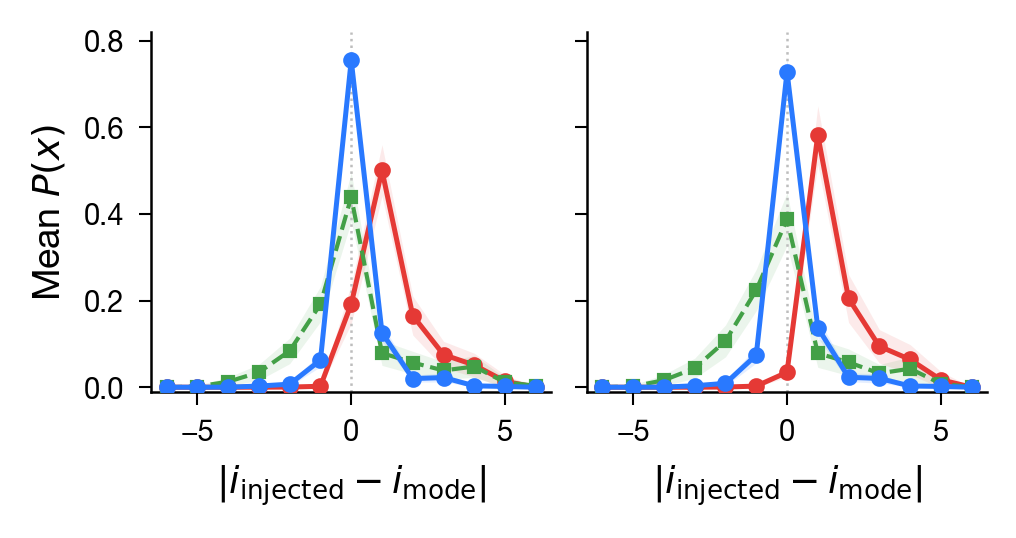

In [21]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 9,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
    "figure.dpi": 300,
    "figure.facecolor": "white",
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 1.2,
    "lines.markersize": 3.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ── Load data ──
baseline_path = "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study1/phi4_study1_baseline_results.jsonl"
exp_path = "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/phi4_study2_testing_results.jsonl"

with open(baseline_path, "r", encoding="utf-8") as f:
    baselines = [json.loads(line) for line in f if line.strip()]
with open(exp_path, "r", encoding="utf-8") as f:
    exp_rows = [json.loads(line) for line in f if line.strip()]

bl_lookup = {}
for b in baselines:
    qid = b["metadata"]["qid"]
    probs = {int(k): v for k, v in b["response"]["probs"].items()}
    mode = int(b["response"]["answer"])
    bl_lookup[qid] = {"probs": probs, "mode": mode}

trials = defaultdict(dict)
for r in exp_rows:
    m = r["metadata"]
    key = (m["qid"], m["irrational_choice"])
    trials[key][m["condition"]] = r

# ── Build records ──
records = []
for (qid, irr), conds in trials.items():
    d1_row = conds.get("memory_justify")
    d2_row = conds.get("memory_justify_correction")
    bl = bl_lookup.get(qid)
    if not d1_row or not d2_row or not bl:
        continue
    mode = bl["mode"]
    p_irr_d1 = d1_row["response"]["probs"].get(str(irr), 0)
    p_mode_d1 = d1_row["response"]["probs"].get(str(mode), 0)

    dist_d0 = np.array([bl["probs"].get(i, 0) for i in range(1, 8)])
    dist_d1 = np.array([d1_row["response"]["probs"].get(str(i), 0) for i in range(1, 8)])
    dist_d2 = np.array([d2_row["response"]["probs"].get(str(i), 0) for i in range(1, 8)])

    records.append({
        "irr": irr, "mode": mode,
        "committed": p_irr_d1 > p_mode_d1,
        "dist_d0": dist_d0, "dist_d1": dist_d1, "dist_d2": dist_d2,
    })

all_trials = records
committed = [r for r in records if r["committed"]]


# ── Helpers ──
def reindex_dist(dist_array, mode, irr):
    sign = 1 if irr >= mode else -1
    result = {}
    for pos_idx, prob in enumerate(dist_array):
        pos = pos_idx + 1
        d = (pos - mode) * sign
        result[d] = result.get(d, 0) + prob
    return result


def aggregate_dists(records, key):
    dist_accum = defaultdict(list)
    for r in records:
        reindexed = reindex_dist(r[key], r["mode"], r["irr"])
        for d in range(-6, 7):
            dist_accum[d].append(reindexed.get(d, 0))
    mean_dist = {}
    ci95_dist = {}
    for d, vals in dist_accum.items():
        vals = np.array(vals)
        n = len(vals)
        mean_dist[d] = np.mean(vals)
        ci95_dist[d] = 1.96 * np.std(vals, ddof=1) / np.sqrt(n)
    return mean_dist, ci95_dist


# ── Colors ──
C_D0 = "#2979FF"
C_D1 = "#E53935"
C_D2 = "#43A047"


def plot_panel(ax, recs, panel_label, show_legend=False):
    x = np.arange(-6, 7)

    mean_d0, ci_d0 = aggregate_dists(recs, "dist_d0")
    mean_d1, ci_d1 = aggregate_dists(recs, "dist_d1")
    mean_d2, ci_d2 = aggregate_dists(recs, "dist_d2")

    y0 = np.array([mean_d0.get(d, 0) for d in x])
    y1 = np.array([mean_d1.get(d, 0) for d in x])
    y2 = np.array([mean_d2.get(d, 0) for d in x])
    c0 = np.array([ci_d0.get(d, 0) for d in x])
    c1 = np.array([ci_d1.get(d, 0) for d in x])
    c2 = np.array([ci_d2.get(d, 0) for d in x])

    ax.fill_between(x, y0 - c0, y0 + c0, alpha=0.12, color=C_D0, linewidth=0)
    ax.fill_between(x, y1 - c1, y1 + c1, alpha=0.10, color=C_D1, linewidth=0)
    ax.fill_between(x, y2 - c2, y2 + c2, alpha=0.10, color=C_D2, linewidth=0)

    ax.plot(x, y0, "o-", color=C_D0, markersize=3, linewidth=1.2,
            label="baseline", zorder=4)
    ax.plot(x, y1, "o-", color=C_D1, markersize=3, linewidth=1.2,
            label="post-injection", zorder=3)
    ax.plot(x, y2, "s--", color=C_D2, markersize=2.5, linewidth=1.0,
            label="post-correction", zorder=3)

    ax.axvline(0, color="#BDBDBD", linestyle=":", linewidth=0.6, zorder=1)

    ax.text(0.03, 0.96, panel_label, transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top", ha="left")

    ax.set_xlabel(r"$|i_{\text{injected}} - i_{\text{mode}}|$")
    ax.set_ylabel(r"Mean $P(x)$")
    ax.set_xlim(-6.5, 6.5)
    ax.set_ylim(bottom=-0.01)

# ── Figure: use smaller physical size so fonts don't shrink in paper ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(3.4, 1.8), sharey=True)

plot_panel(ax1, all_trials, "", show_legend=True)
plot_panel(ax2, committed, "", show_legend=False)

ax2.set_ylabel("")

plt.tight_layout(w_pad=0.8)
plt.savefig("fig_study2_distribution_shift_phi.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("fig_study2_distribution_shift_phi.pdf", bbox_inches="tight", facecolor="white")
plt.show()
